In [ ]:
from pypot.dynamixel import DxlIO
from pypot.dynamixel.protocol.v1 import *

from glob import glob
import struct

#ports = glob('/dev/ttyACM*')
ports = glob('/dev/ttyUSB*')

assert len(ports) == 1

port = ports[0]
print('Connecting on port: {}'.format(port))
dxl_io = DxlIO(port,baudrate=2000000, timeout=0.01)

poulpe_id = 42
N_AXIS = 2 #here to select if Orbita2D or Orbita3D

In [2]:
dxl_io.flush()

In [3]:
ping_packet = DxlPingPacket(poulpe_id)
dxl_io._send_packet(ping_packet)

DxlStatusPacket(id=42, error=0, parameters=())

In [4]:
import struct

def read_current_pos():
    pos_packet = DxlReadDataPacket(poulpe_id, 50, N_AXIS * 4)
    resp = dxl_io._send_packet(pos_packet)
    data = bytearray(resp.parameters)
    pos = struct.unpack(N_AXIS * 'f', data)
    return pos

read_current_pos()

(0.0012550214305520058, 0.00033026881283149123)

In [5]:
def read_current_vel():
    pos_packet = DxlReadDataPacket(poulpe_id, 51, N_AXIS * 4)
    resp = dxl_io._send_packet(pos_packet)
    data = bytearray(resp.parameters)
    res = struct.unpack(N_AXIS * 'f', data)
    return res

read_current_vel()

(-8.407790785948902e-45, -7.006492321624085e-45)

In [6]:
def read_current_torque():
    pos_packet = DxlReadDataPacket(poulpe_id, 52, N_AXIS * 4)
    resp = dxl_io._send_packet(pos_packet)
    data = bytearray(resp.parameters)
    res = struct.unpack(N_AXIS * 'f', data)
    return res

read_current_torque()

(-293.30645751953125, 161.8714141845703)

In [7]:
def read_target_position():
    pos_packet = DxlReadDataPacket(poulpe_id, 60, N_AXIS * 4)
    resp = dxl_io._send_packet(pos_packet,wait_for_status_packet=True)
    data = bytearray(resp.parameters)
    pos = struct.unpack(N_AXIS * 'f', data)
    return pos

read_target_position()

(0.0, 0.0)

In [92]:
def read_axis_sensor(): #Ring/Center sensors for Orbita2D, Gearbox output sensors for Orbita3d
    pos_packet = DxlReadDataPacket(poulpe_id, 90, N_AXIS * 4)
    resp = dxl_io._send_packet(pos_packet,wait_for_status_packet=True)
    data = bytearray(resp.parameters)
    pos = struct.unpack(N_AXIS * 'f', data)
    return pos

axis_readings_initial = np.array(read_axis_sensor())
axis_readings_initial

array([5.16932344, 2.54733062])

In [9]:
def read_velocity_limit():
    packet = DxlReadDataPacket(poulpe_id, 10, N_AXIS * 4)
    resp = dxl_io._send_packet(packet,wait_for_status_packet=True)
    data = bytearray(resp.parameters)
    pos = struct.unpack(N_AXIS * 'f', data)
    return pos

read_velocity_limit()

(10.306746482849121, 10.306746482849121)

In [10]:
def read_velocity_feedforward():
    pos_packet = DxlReadDataPacket(poulpe_id, 54, N_AXIS * 4)
    resp = dxl_io._send_packet(pos_packet,wait_for_status_packet=True)
    data = bytearray(resp.parameters)
    pos = struct.unpack(N_AXIS * 'f', data)
    return pos

read_velocity_feedforward()

(0.0, 0.0)

In [11]:
def write_velocity_limit(data): #array of N_AXIS*u32
    packet = DxlWriteDataPacket(poulpe_id, 10, struct.pack(N_AXIS * 'f', *data))
    resp = dxl_io._send_packet(packet,wait_for_status_packet=True)
    return resp

In [15]:
def write_velocity_feedforward(data): #array of N_AXIS*u32
    packet = DxlWriteDataPacket(poulpe_id, 54, struct.pack(N_AXIS * 'f', *data))
    resp = dxl_io._send_packet(packet,wait_for_status_packet=True)
    return resp
write_velocity_feedforward([0, 0])

DxlStatusPacket(id=42, error=0, parameters=())

In [14]:
def read_torqueflux_limit():
    packet = DxlReadDataPacket(poulpe_id, 14, N_AXIS * 2)
    resp = dxl_io._send_packet(packet,wait_for_status_packet=True)
    data = bytearray(resp.parameters)
    pos = struct.unpack(N_AXIS * 'f', data)
    return pos

read_torqueflux_limit()

(29461.35546875, 29461.35546875)

In [17]:
def write_torqueflux_limit(data): #array of N_AXIS*u16
    packet = DxlWriteDataPacket(poulpe_id, 14, struct.pack(N_AXIS * 'f', *data))
    resp = dxl_io._send_packet(packet,wait_for_status_packet=True)
    return resp

In [18]:
def read_uqud_limit():
    packet = DxlReadDataPacket(poulpe_id, 18, N_AXIS * 2)
    resp = dxl_io._send_packet(packet,wait_for_status_packet=True)
    data = bytearray(resp.parameters)
    pos = struct.unpack(N_AXIS * 'h', data)
    return pos

read_uqud_limit()

(32767, 32767)

In [19]:
def write_uqud_limit(data): #array of N_AXIS*i16
    packet = DxlWriteDataPacket(poulpe_id, 18, struct.pack(N_AXIS * 'h', *data))
    resp = dxl_io._send_packet(packet,wait_for_status_packet=True)
    return resp

In [20]:
def read_flux_pid(): #array of N_AXIS*[i,p] in int16
    packet = DxlReadDataPacket(poulpe_id, 20, N_AXIS * 4)
    resp = dxl_io._send_packet(packet,wait_for_status_packet=True)
    data = bytearray(resp.parameters)
    pos = struct.unpack(2*N_AXIS * 'h', data)
    return pos

read_flux_pid()

(0, 800, 0, 800)

In [21]:
def write_flux_pid(data): #array of N_AXIS*[i,p] in int16
    packet = DxlWriteDataPacket(poulpe_id, 20, struct.pack(2*N_AXIS * 'h', *data))
    resp = dxl_io._send_packet(packet,wait_for_status_packet=True)
    return resp

In [22]:
def read_torque_pid(): #array of N_AXIS*[i,p] in int16
    packet = DxlReadDataPacket(poulpe_id, 24, N_AXIS * 4)
    resp = dxl_io._send_packet(packet,wait_for_status_packet=True)
    data = bytearray(resp.parameters)
    pos = struct.unpack(2*N_AXIS * 'h', data)
    return pos

read_torque_pid()

(0, 800, 0, 800)

In [23]:
def write_torque_pid(data): #array of N_AXIS*[i,p] in int16
    packet = DxlWriteDataPacket(poulpe_id, 24, struct.pack(2*N_AXIS * 'h', *data))
    resp = dxl_io._send_packet(packet,wait_for_status_packet=True)
    return resp

In [24]:
def read_velocity_pid(): #array of N_AXIS*[i,p] in int16
    packet = DxlReadDataPacket(poulpe_id, 28, N_AXIS * 4)
    resp = dxl_io._send_packet(packet,wait_for_status_packet=True)
    data = bytearray(resp.parameters)
    pos = struct.unpack(2*N_AXIS * 'h', data)
    return pos

read_velocity_pid()

(450, 500, 450, 500)

In [25]:
def write_velocity_pid(data): #array of N_AXIS*[i,p] in int16
    packet = DxlWriteDataPacket(poulpe_id, 28, struct.pack(2*N_AXIS * 'h', *data))
    resp = dxl_io._send_packet(packet,wait_for_status_packet=True)
    return resp

In [26]:
def read_position_pid(): #array of N_AXIS*[i,p] in int16
    packet = DxlReadDataPacket(poulpe_id, 32, N_AXIS * 4)
    resp = dxl_io._send_packet(packet,wait_for_status_packet=True)
    data = bytearray(resp.parameters)
    pos = struct.unpack(2*N_AXIS * 'h', data)
    return pos

read_position_pid()

(0, 80, 0, 80)

In [27]:
def write_position_pid(data): #array of N_AXIS*[i,p] in int16
    packet = DxlWriteDataPacket(poulpe_id, 32, struct.pack(2*N_AXIS * 'h', *data))
    resp = dxl_io._send_packet(packet,wait_for_status_packet=True)
    return resp

In [29]:
write_position_pid([1,16,2,32])

DxlStatusPacket(id=42, error=0, parameters=())

In [30]:
def parse_state(data):
    #target=struct.unpack(N_AXIS * 'f', data[0:4*N_AXIS])
    #pos = struct.unpack(N_AXIS * 'f', data[4*N_AXIS:2*4*N_AXIS])
    #vel = struct.unpack(N_AXIS * 'f', data[2*4*N_AXIS:3*4*N_AXIS])
    #torque = struct.unpack(N_AXIS * 'f', data[3*4*N_AXIS:4*4*N_AXIS])
    #torque_on = struct.unpack(N_AXIS * '?', data[4*4*N_AXIS:(4*4+1)*N_AXIS])

    pos = struct.unpack(N_AXIS * 'f', data[0:4*N_AXIS])
    vel = struct.unpack(N_AXIS * 'f', data[4*N_AXIS:2*4*N_AXIS])
    torque = struct.unpack(N_AXIS * 'f', data[2*4*N_AXIS:3*4*N_AXIS])

    return pos, vel, torque

def read_full_state(): #Returns (position*N_AXIS, velocity*N_AXIS, torque*N_AXIS)
    pos_packet = DxlReadDataPacket(poulpe_id, 100, N_AXIS * (4*4))
    resp = dxl_io._send_packet(pos_packet,wait_for_status_packet=True)
    data = bytearray(resp.parameters)
    return parse_state(data)

read_full_state()

((0.0012550214305520058, 0.00033026881283149123),
 (-8.407790785948902e-45, -7.006492321624085e-45),
 (-285.9989013671875, 161.8124237060547))

In [33]:
def write_target_position(target): #Returns a "full_state"
    p = DxlWriteDataPacket(poulpe_id, 60, struct.pack(N_AXIS * 'f', *target))
    resp = dxl_io._send_packet(p,wait_for_status_packet=True)
    #print(resp)
    return parse_state(bytearray(resp.parameters))

write_target_position([0.0, 0.0])
# write_target_position([0.0, 0.0, 0.0])

((0.0012550214305520058, 0.00033026881283149123),
 (-8.407790785948902e-45, -7.006492321624085e-45),
 (-286.4236145019531, 160.00157165527344))

In [34]:
# data contains first two positions, then two velocities
def write_target_position_with_velocity_ff(data): #Returns a "full_state"
    p = DxlWriteDataPacket(poulpe_id, 62, struct.pack(2*N_AXIS * 'f', *data))
    resp = dxl_io._send_packet(p,wait_for_status_packet=True)
    #print(resp)
    return parse_state(bytearray(resp.parameters))

# data contains two target positions, the two velocities are estimated in the firmware
def write_target_position_estimate_velocity_ff(data): #Returns a "full_state"
    p = DxlWriteDataPacket(poulpe_id, 64, struct.pack(N_AXIS * 'f', *data))
    resp = dxl_io._send_packet(p,wait_for_status_packet=True)
    #print(resp)
    return parse_state(bytearray(resp.parameters))


# write_target_position([0.5, 0.5])
write_target_position_with_velocity_ff([0.0, 0.0, 0.0, 0.0])

((0.0012550214305520058, 0.00033026881283149123),
 (-8.407790785948902e-45, -7.006492321624085e-45),
 (-287.7489013671875, 162.1513671875))

In [35]:
def read_torque_enabled():
    p = DxlReadDataPacket(poulpe_id, 40, N_AXIS)
    resp = dxl_io._send_packet(p)
    data = bytearray(resp.parameters)
    torque = struct.unpack(N_AXIS * '?', data)
    return torque

read_torque_enabled()

(False, False)

In [36]:
def write_torque_enabled(torque):
    p = DxlWriteDataPacket(poulpe_id, 40, struct.pack(N_AXIS * '?', *torque))
    resp = dxl_io._send_packet(p)
    return resp

#write_torque_enabled([False, False])
write_torque_enabled([False, False, False])

error: pack expected 2 items for packing (got 3)

In [56]:
write_torque_enabled([True, True])
# write_torque_enabled([True, True, True])

DxlStatusPacket(id=42, error=0, parameters=())

In [118]:
import time
import numpy as np

pos = []
send_target, send_target_time = [], []
axis_readings, axis_reading_time = [], []
state, state_time = [], []
torque = []
vel = []
t0 = time.time()
freq=1.5
t_delay = 0.0005
cur=read_current_pos()
nbok=0
nberr=0
while True:
    if time.time() - t0 > 10:
        break

    target = [
        np.radians(10) * np.sin(2 * np.pi * freq * (time.time()-t0)), 
        np.radians(10) * np.sin(2 * np.pi * freq * (time.time()-t0)),
        #np.radians(2*360.0) * np.sin(2 * np.pi * freq * (time.time()-t0)),
    ]
    try:
        # 5 secs of pure position control
        # and then 5 secs of position control with velocity feedforward
        if time.time() - t0 > 5:
            state.append(write_target_position(target))
        else:
            state.append(write_target_position_estimate_velocity_ff(target))
            
        state_time.append(time.time())
        send_target.append(target)
        send_target_time.append(target)
        # add axis output sensors
        axis_readings.append(read_axis_sensor())
        axis_reading_time.append(time.time())
        nbok+=1
    except:
        nberr+=1
        #print('err')
    time.sleep(t_delay)
print(f'ok: {nbok} err: {nberr} ratio: {nberr/nbok}')

write_target_position([0.0, 0.0])
state = np.array(state)
state_time = np.array(state_time) - state_time[0]
axis_readings = np.array(axis_readings)
axis_reading_time = np.array(axis_reading_time) - axis_reading_time[0]

ok: 2447 err: 3 ratio: 0.0012259910093992644


In [119]:
import matplotlib.pyplot as plt
%matplotlib inline

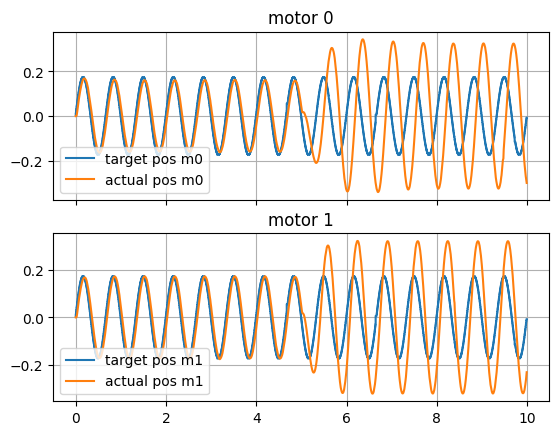

In [120]:
fig, axs = plt.subplots(2, sharex=True)
send_target = np.array(send_target)
pos = np.array(pos)
for i, a in enumerate(axs):
    a.set_title("motor {}".format(i))
    a.step(state_time, np.array(send_target[:,i]), label="target pos m{}".format(i))
    a.plot(state_time,np.array(state[:,0,i]), label="actual pos m{}".format(i))
    a.legend()
    a.grid()
    

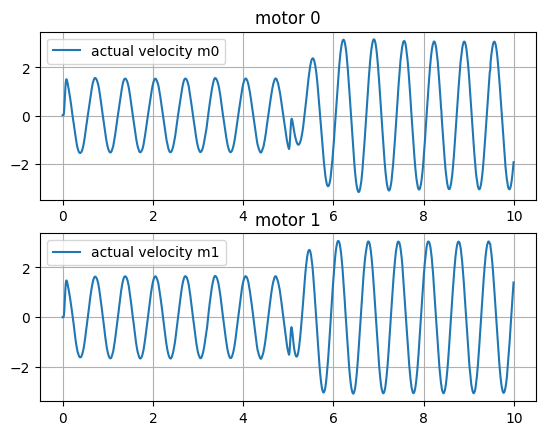

In [128]:
fig, axs = plt.subplots(2)
vel = state[:,1,:].copy()
vel_filt = np.array(vel)
vel_filt[(vel_filt > 40) | (vel_filt < -40)]= 0
vel_filt = np.array(vel_filt)
for i, a in enumerate(axs):
    a.set_title("motor {}".format(i))
    a.plot(state_time,np.array(vel_filt[:,i]), label="actual velocity m{}".format(i),zorder=30)
    a.legend()
    a.grid()

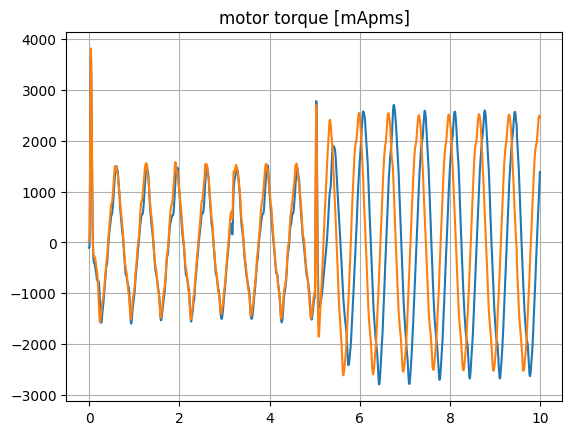

In [122]:
plt.figure()
plt.plot(state_time,np.array(state[:,2,:]))
plt.title("motor torque [mApms]")
plt.grid()

Text(0.5, 1.0, 'center sensor')

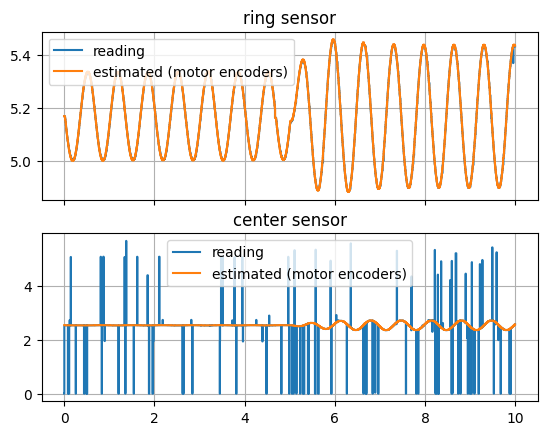

In [127]:
fig, axs = plt.subplots(2, sharex=True)
axis_readings = np.array(axis_readings)
axis_reading_time = np.array(axis_reading_time) - axis_reading_time[0]
axis_calc = -np.array([(state[:,0,0]+state[:,0,1])/2.0, (state[:,0,0]-state[:,0,1])/2]) + axis_readings_initial[:,None]
pos = np.array(pos)

for i, a in enumerate(axs):
    if i > 1: break
    a.step(axis_reading_time, axis_readings[:,i], label='reading')
    a.step(state_time, (axis_calc[i,:] % (2*np.pi)), label="estimated (motor encoders)")
    a.legend()
    a.grid()
axs[0].set_title("ring sensor")
axs[1].set_title("center sensor")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


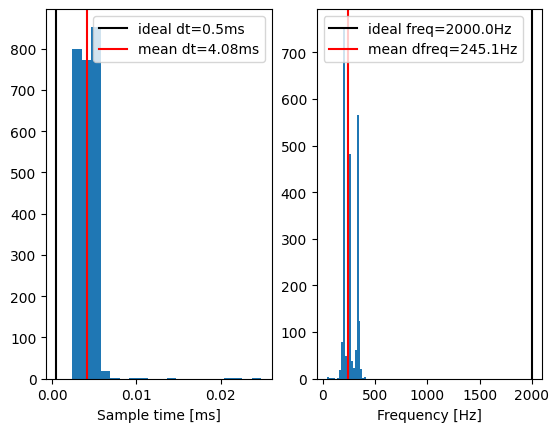

In [126]:
fig, axs = plt.subplots(1,2)
axs[0].hist(np.diff(np.array(state_time)),20)
axs[0].set_xlabel("Sample time [ms]")
axs[0].axvline(t_delay, color='black', label = "ideal dt={}ms".format(t_delay*1000))
dt_mean = np.mean(np.diff(np.array(state_time)))
axs[0].axvline(dt_mean, color='red', label = "mean dt={:.4}ms".format(dt_mean*1000))
axs[0].legend()
axs[1].legend()
axs[1].hist(1/np.diff(np.array(state_time)),20)
axs[1].set_xlabel("Frequency [Hz]")
axs[1].axvline(1/t_delay, color='black', label = "ideal freq={}Hz".format(1/t_delay))
axs[1].axvline(1/dt_mean, color='red', label = "mean dfreq={:.4}Hz".format(1/dt_mean))
axs[1].legend()